# Customer Churn Prediction - Telco Dataset

Prédiction du churn des clients d'une entreprise de télécommunications.

Dataset: Telco Customer Churn (Kaggle)  
Modèles: Logistic Regression, Random Forest, XGBoost


In [335]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

import warnings
warnings.filterwarnings('ignore')

# packages
try:
    import xgboost as xgb
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


## 1. Chargement des données

In [336]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()


Dataset : 7043 lignes, 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploration des données


In [337]:
print(f"Shape: {df.shape}")
print(f"\nColonnes: {list(df.columns)}")
print(f"\nTypes de données:")
print(df.dtypes)


Shape: (7043, 21)

Colonnes: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Types de données:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [338]:
missing = df.isnull().sum()
if missing.sum() > 0:
    print("Valeurs manquantes:")
    print(missing[missing > 0])
else:
    print("Aucune valeur manquante")

empty_total = (df['TotalCharges'] == ' ') | (df['TotalCharges'] == '')
print(f"\nValeurs vides dans TotalCharges: {empty_total.sum()}")


Aucune valeur manquante

Valeurs vides dans TotalCharges: 11


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Taux de churn: 26.54%


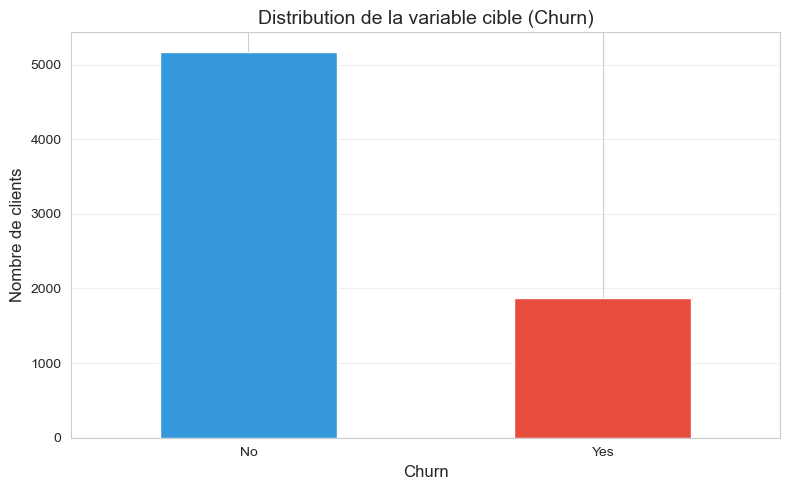

In [339]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nTaux de churn: {(churn_counts['Yes'] / len(df) * 100):.2f}%")

plt.figure(figsize=(8, 5))
churn_counts.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Distribution de la variable cible (Churn)', fontsize=14)
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Nombre de clients', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Nettoyage des données
Nettoyons les données en gérant les valeurs manquantes et en préparant les colonnes.



In [340]:
df_clean = df.copy()

if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop('customerID', axis=1)

df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
missing_count = df_clean['TotalCharges'].isnull().sum()
if missing_count > 0:
    df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)
    print(f"{missing_count} valeurs manquantes dans 'TotalCharges' remplacées par 0")

print(f"Shape après nettoyage: {df_clean.shape}")


11 valeurs manquantes dans 'TotalCharges' remplacées par 0
Shape après nettoyage: (7043, 20)


## 4. Encodage des variables catégorielles


In [341]:
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

df_encoded = df_clean.copy()
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

if 'Churn' in df_encoded.columns:
    df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

print(f"Encodage terminé. Shape: {df_encoded.shape}")


Encodage terminé. Shape: (7043, 20)


## 5. Feature Engineering


In [342]:
df_fe = df_encoded.copy()

df_fe['ChargeRatio'] = np.where(
    df_fe['TotalCharges'] > 0,
    df_fe['MonthlyCharges'] / (df_fe['TotalCharges'] + 1),
    0
)
print("Crée: ChargeRatio")

df_fe['TenureGroup'] = pd.cut(
    df_fe['tenure'],
    bins=[0, 12, 24, 48, 100],
    labels=[0, 1, 2, 3],
    include_lowest=True
)
df_fe['TenureGroup'] = df_fe['TenureGroup'].fillna(0).astype(int)
print("Crée: TenureGroup")

service_cols = [col for col in df_fe.columns if any(s in col.lower() 
                for s in ['phone', 'internet', 'streaming', 'security', 'backup', 'protection', 'support'])]
df_fe['TotalServices'] = (df_fe[service_cols] > 0).sum(axis=1)
print(f"Crée: TotalServices ({len(service_cols)} services)")

threshold = df_fe['MonthlyCharges'].quantile(0.75)
df_fe['HighValueCustomer'] = (df_fe['MonthlyCharges'] > threshold).astype(int)
print(f"Crée: HighValueCustomer (threshold: {threshold:.2f})")

print(f"\nFeatures avant: {df_encoded.shape[1]}")
print(f"Features après: {df_fe.shape[1]}")
print(f"Nouvelles features: {df_fe.shape[1] - df_encoded.shape[1]}")

df_encoded = df_fe


Crée: ChargeRatio
Crée: TenureGroup
Crée: TotalServices (8 services)
Crée: HighValueCustomer (threshold: 89.85)

Features avant: 20
Features après: 24
Nouvelles features: 4


## 6. Analyse de corrélation


Les 10 features les plus corrélées avec churn
----------------------------------------
ChargeRatio          0.322069
MonthlyCharges       0.193356
PaperlessBilling     0.191825
SeniorCitizen        0.150889
PaymentMethod        0.107062
HighValueCustomer    0.082833
MultipleLines        0.038037
PhoneService         0.011942
gender              -0.008612
StreamingTV         -0.036581
Les 10 features les moins corrélées avec churn
----------------------------------------
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.198324
TechSupport        -0.282492
TotalServices      -0.288468
OnlineSecurity     -0.289309
TenureGroup        -0.345410
tenure             -0.352229
Contract           -0.396713


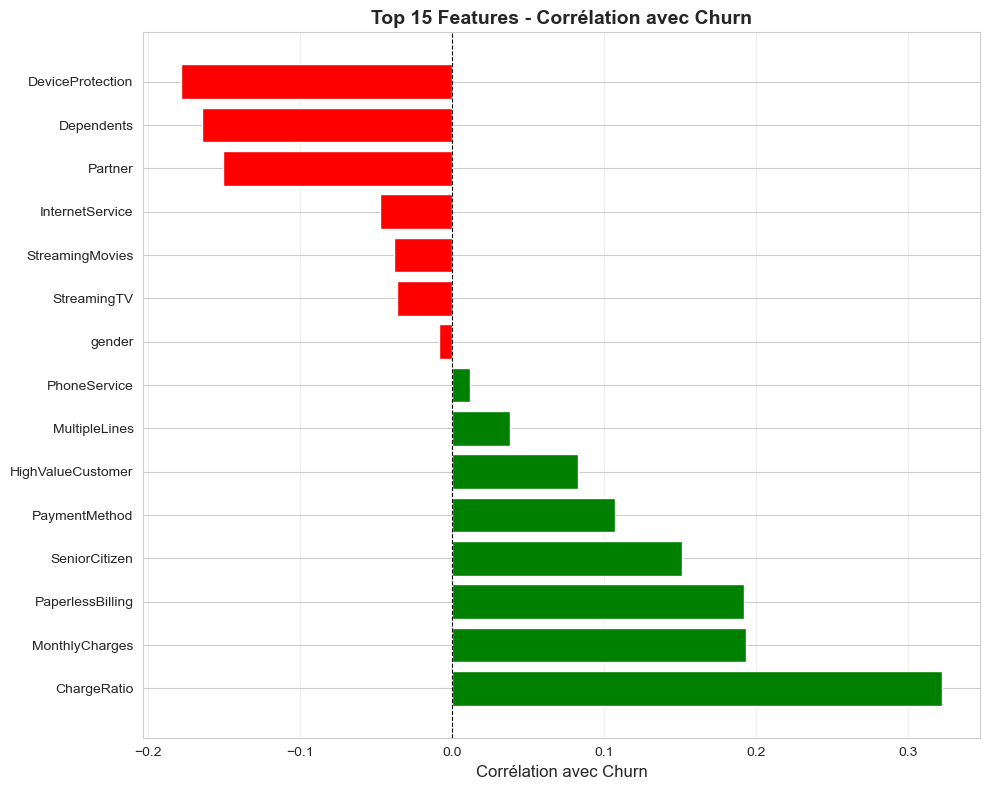

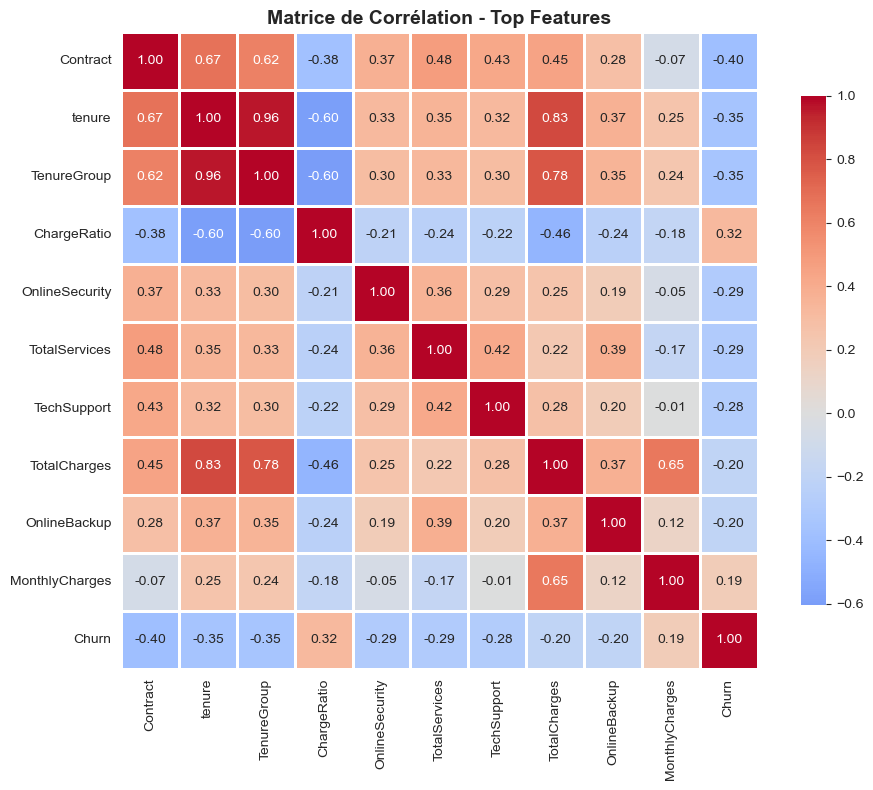

In [343]:
# calcule
correlations = df_encoded.corr()['Churn'].sort_values(ascending=False)

# enlève la corrélation avec elle-même
correlations = correlations[correlations.index != 'Churn']

print("Les 10 features les plus corrélées avec churn")
print("-"*40)
print(correlations.head(10).to_string())

print("Les 10 features les moins corrélées avec churn")
print("-"*40)
print(correlations.tail(10).to_string())

# visualisation
plt.figure(figsize=(10, 8))
top_corr = correlations.head(15)
colors = ['red' if x < 0 else 'green' for x in top_corr.values]
plt.barh(range(len(top_corr)), top_corr.values, color=colors)
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('Corrélation avec Churn', fontsize=12)
plt.title('Top 15 Features - Corrélation avec Churn', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# matrice de corrélation pour les top features
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
if 'Churn' in numeric_cols:
        numeric_cols.remove('Churn')

# top features pour la matrice
top_features = correlations.abs().nlargest(10).index.tolist()
if 'Churn' not in top_features:
        top_features.append('Churn')

if len(top_features) > 1:
        plt.figure(figsize=(10, 8))
        corr_matrix = df_encoded[top_features].corr()
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
        plt.title('Matrice de Corrélation - Top Features', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()


## 7. Préparation des features et de la variable cible


In [344]:
# séparation des features et de la variable cible
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nColonnes des features: {list(X.columns)}")
print(f"\nDistribution de la variable cible:")
print(y.value_counts())
print(f"\nTaux de churn: {(y.sum() / len(y) * 100):.2f}%")


Features (X): (7043, 23)
Target (y): (7043,)

Colonnes des features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'ChargeRatio', 'TenureGroup', 'TotalServices', 'HighValueCustomer']

Distribution de la variable cible:
Churn
0    5174
1    1869
Name: count, dtype: int64

Taux de churn: 26.54%


## 8. Division Train/Test


In [345]:
# avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ensemble d'entraînement: {X_train.shape[0]} échantillons (taux de churn: {(y_train.sum() / len(y_train) * 100):.2f}%)")
print(f"Ensemble de test: {X_test.shape[0]} échantillons (taux de churn: {(y_test.sum() / len(y_test) * 100):.2f}%)")


Ensemble d'entraînement: 5634 échantillons (taux de churn: 26.54%)
Ensemble de test: 1409 échantillons (taux de churn: 26.54%)


## 9. Gestion du déséquilibre (SMOTE)

Avant SMOTE:
  Classe 0 (No Churn): 4139 (73.46%)
  Classe 1 (Churn): 1495 (26.54%)

Après SMOTE:
  Classe 0 (No Churn): 4139 (50.00%)
  Classe 1 (Churn): 4139 (50.00%)

Nouvelle taille: 8278 échantillons


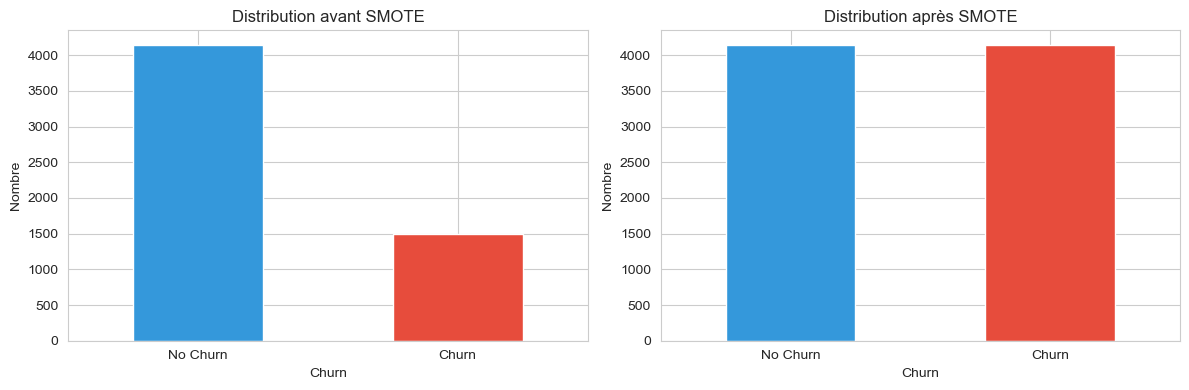

In [346]:
# application de SMOTE pour équilibrer les classes
print("Avant SMOTE:")
print(f"  Classe 0 (No Churn): {(y_train == 0).sum()} ({((y_train == 0).sum() / len(y_train) * 100):.2f}%)")
print(f"  Classe 1 (Churn): {(y_train == 1).sum()} ({((y_train == 1).sum() / len(y_train) * 100):.2f}%)")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAprès SMOTE:")
print(f"  Classe 0 (No Churn): {(y_train_balanced == 0).sum()} ({((y_train_balanced == 0).sum() / len(y_train_balanced) * 100):.2f}%)")
print(f"  Classe 1 (Churn): {(y_train_balanced == 1).sum()} ({((y_train_balanced == 1).sum() / len(y_train_balanced) * 100):.2f}%)")
print(f"\nNouvelle taille: {len(X_train_balanced)} échantillons")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.Series(y_train).value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Distribution avant SMOTE')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Nombre')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

pd.Series(y_train_balanced).value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'])
axes[1].set_title('Distribution après SMOTE')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Nombre')
axes[1].set_xticklabels(['No Churn', 'Churn'], rotation=0)

plt.tight_layout()
plt.show()

X_train_final = X_train_balanced
y_train_final = y_train_balanced


## 10. Entraînement des modèles
Entraînons deux modèles de classification :
1. **Logistic Regression** (modèle linéaire)
2. **Random Forest** (modèle d'ensemble)



In [347]:
# standardisation des features pour régression logistique (sur données après SMOTE)
scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test)


## 11. Validation Croisée


In [348]:
# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_final_scaled, y_train_final)
lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]


Logistic Regression - F1 CV: 0.8232 (+/- 0.0132)
Random Forest - F1 CV: 0.8562 (+/- 0.0100)
XGBoost - F1 CV: 0.8459 (+/- 0.0103)


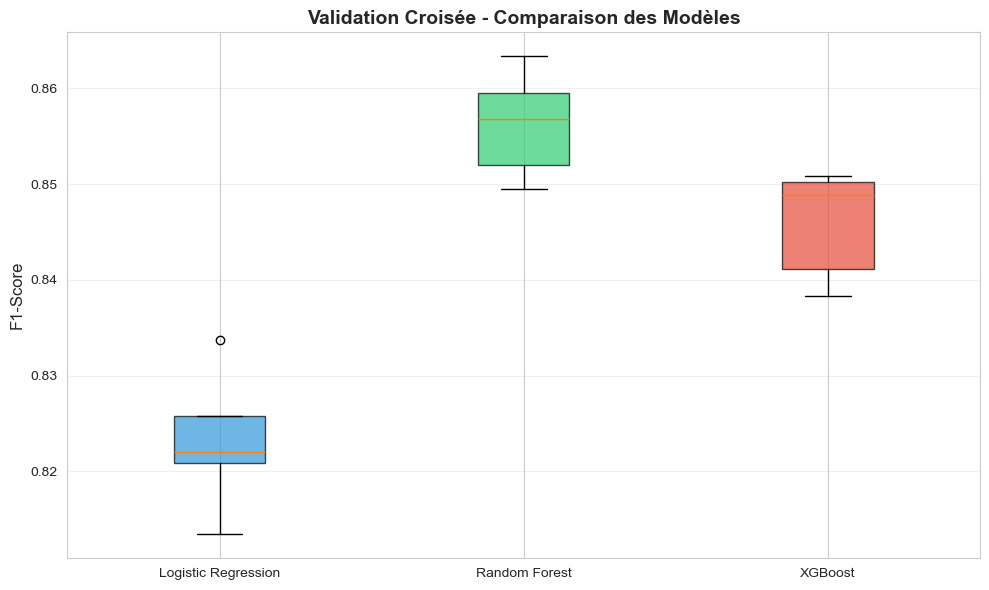

In [349]:
# validation croisée 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

# standardise X_train_final pour logistic regression
scaler_cv = StandardScaler()
X_train_final_scaled = scaler_cv.fit_transform(X_train_final)
lr_cv_scores = cross_val_score(lr_model, X_train_final_scaled, y_train_final, 
                              cv=cv, scoring='f1', n_jobs=-1)
cv_results['Logistic Regression'] = lr_cv_scores
print(f"Logistic Regression - F1 CV: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std()*2:.4f})")

# random forest
rf_cv_scores = cross_val_score(rf_model, X_train_final, y_train_final, 
                              cv=cv, scoring='f1', n_jobs=-1)
cv_results['Random Forest'] = rf_cv_scores
print(f"Random Forest - F1 CV: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std()*2:.4f})")

# xgboost
xgb_cv_scores = cross_val_score(xgb_model, X_train_final, y_train_final, 
                               cv=cv, scoring='f1', n_jobs=-1)
cv_results['XGBoost'] = xgb_cv_scores
print(f"XGBoost - F1 CV: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std()*2:.4f})")

# visualisation
plt.figure(figsize=(10, 6))
data_to_plot = [cv_results[k] for k in cv_results.keys()]
bp = plt.boxplot(data_to_plot, labels=list(cv_results.keys()), patch_artist=True)
colors = ['#3498db', '#2ecc71', '#e74c3c']
for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.ylabel('F1-Score', fontsize=12)
plt.title('Validation Croisée - Comparaison des Modèles', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 3. XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_random = RandomizedSearchCV(
    xgb_base, param_dist_xgb,
    n_iter=15, cv=5, scoring='f1',
    n_jobs=-1, random_state=42, verbose=0
)

xgb_random.fit(X_train_final, y_train_final)
xgb_model = xgb_random.best_estimator_
xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]


In [351]:
# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_final, y_train_final)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]


## 12. Évaluation des modèles


In [352]:
# fonction pour calculer toutes les métriques
def calculate_metrics(y_true, y_pred, model_name):
    """Calcule et affiche les métriques de classification"""
    if y_true is None or y_pred is None:
        return None
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{model_name} - Métriques:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

# évaluation
lr_metrics = calculate_metrics(y_test, lr_pred, "régression logistique")



régression logistique - Métriques:
  Accuracy:  0.7573
  Precision: 0.5329
  Recall:    0.6925
  F1-Score:  0.6023


## 13. Courbes ROC et Precision-Recall


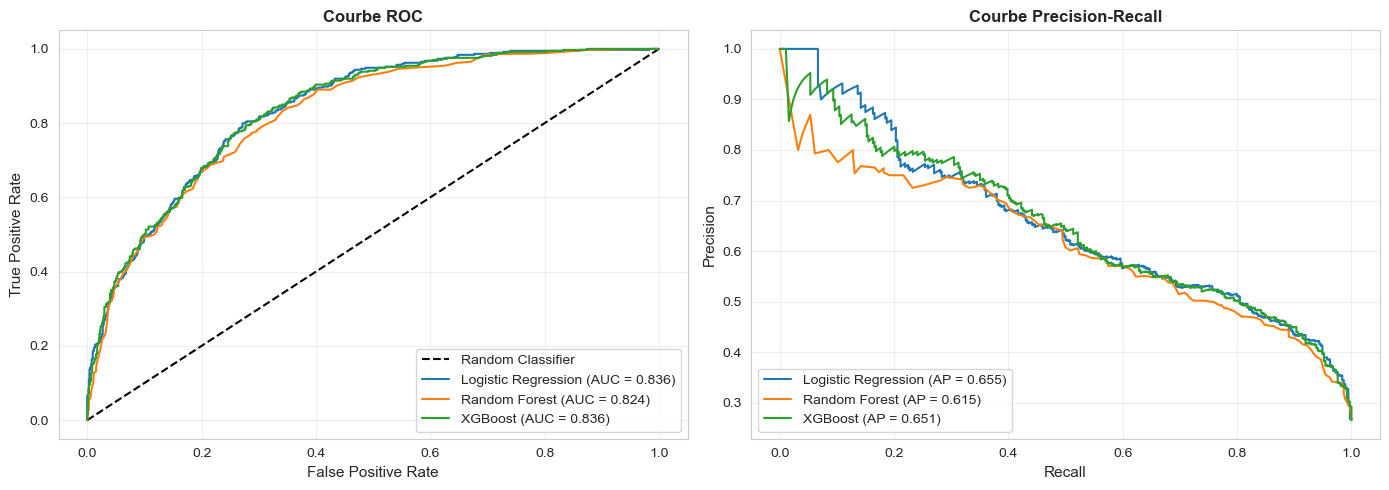

In [353]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# courbe ROC
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
auc_lr = roc_auc_score(y_test, lr_pred_proba)
axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
auc_rf = roc_auc_score(y_test, rf_pred_proba)
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)
auc_xgb = roc_auc_score(y_test, xgb_pred_proba)
axes[0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')

axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Courbe ROC', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# courbe precision-recall
precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_pred_proba)
ap_lr = average_precision_score(y_test, lr_pred_proba)
axes[1].plot(recall_lr, precision_lr, label=f'Logistic Regression (AP = {ap_lr:.3f})')

precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_pred_proba)
ap_rf = average_precision_score(y_test, rf_pred_proba)
axes[1].plot(recall_rf, precision_rf, label=f'Random Forest (AP = {ap_rf:.3f})')

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_pred_proba)
ap_xgb = average_precision_score(y_test, xgb_pred_proba)
axes[1].plot(recall_xgb, precision_xgb, label=f'XGBoost (AP = {ap_xgb:.3f})')

axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Courbe Precision-Recall', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# évaluation random forest
rf_metrics = calculate_metrics(y_test, rf_pred, "Random Forest")

# évaluation xgboost
xgb_metrics = calculate_metrics(y_test, xgb_pred, "XGBoost")



Random Forest - Métriques:
  Accuracy:  0.7729
  Precision: 0.5707
  Recall:    0.5829
  F1-Score:  0.5767

XGBoost - Métriques:
  Accuracy:  0.7672
  Precision: 0.5507
  Recall:    0.6684
  F1-Score:  0.6039


In [355]:
# comparaison des modèles
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
}).T

print("comparaison des modèles")
print("-"*25)
print("\nTableau comparatif:")
print(comparison_df.round(4))

# meilleur modèle selon F1-Score
best_model_name = comparison_df['f1_score'].idxmax()
best_f1 = comparison_df.loc[best_model_name, 'f1_score']
print(f"\nMeilleur modèle (F1-Score): {best_model_name} (F1 = {best_f1:.4f})")


comparaison des modèles
-------------------------

Tableau comparatif:
                     accuracy  precision  recall  f1_score
Logistic Regression    0.7573     0.5329  0.6925    0.6023
Random Forest          0.7729     0.5707  0.5829    0.5767
XGBoost                0.7672     0.5507  0.6684    0.6039

Meilleur modèle (F1-Score): XGBoost (F1 = 0.6039)


## 14. Matrices de confusion


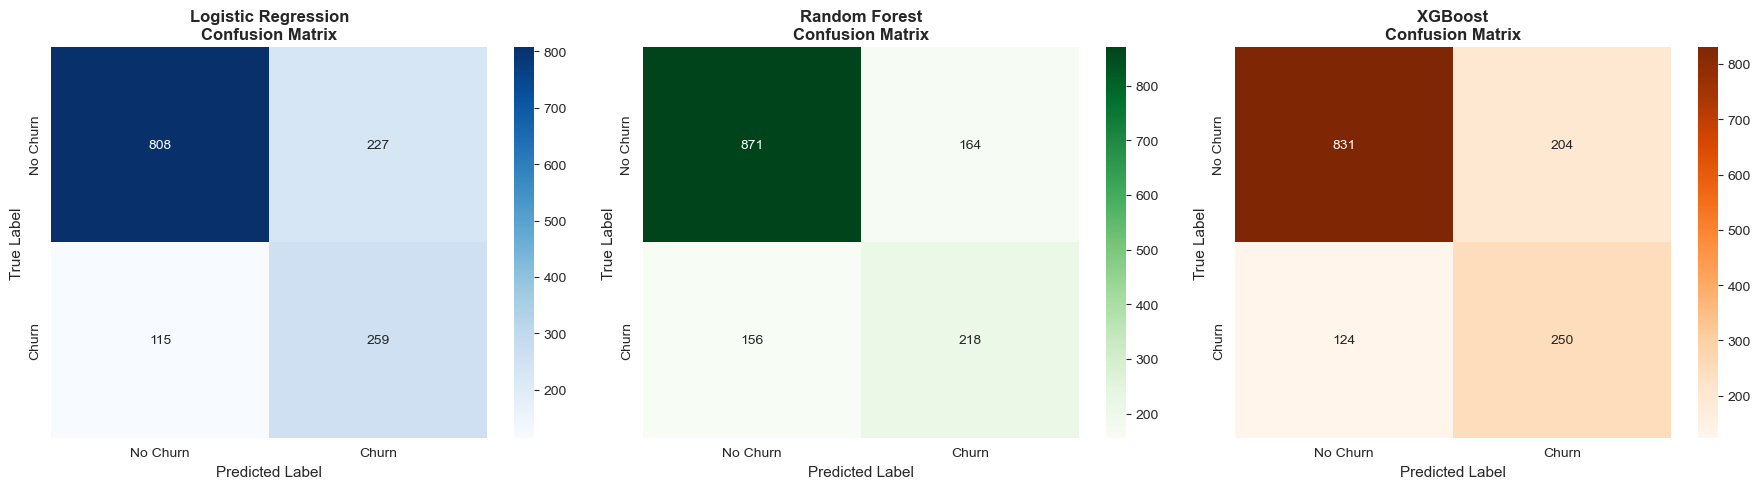

rapport de classification - régression logistique
--------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.88      0.78      0.83      1035
       Churn       0.53      0.69      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.78      0.76      0.77      1409


rapport de classification - random forest
--------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1035
       Churn       0.57      0.58      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409


rapport de classification - xgboost
--------------------------------------------------
              precision    recall  f1-score   support

    No C

In [356]:
# matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# régression logistique
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=['No Churn', 'Churn'],
           yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# random forest
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
           xticklabels=['No Churn', 'Churn'],
           yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

# xgboost
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
           xticklabels=['No Churn', 'Churn'],
           yticklabels=['No Churn', 'Churn'])
axes[2].set_title('XGBoost\nConfusion Matrix', fontsize=12, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=11)
axes[2].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

# rapports de classification
print("rapport de classification - régression logistique")
print("-"*50)
print(classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn']))

print("\nrapport de classification - random forest")
print("-"*50)
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))

print("\nrapport de classification - xgboost")
print("-"*50)
print(classification_report(y_test, xgb_pred, target_names=['No Churn', 'Churn']))


## 15. Visualisation de la comparaison des modèles


Comparaison de l'importance des features

Features communes dans les top 10: 4
  ['Contract', 'OnlineSecurity', 'TenureGroup', 'TechSupport']


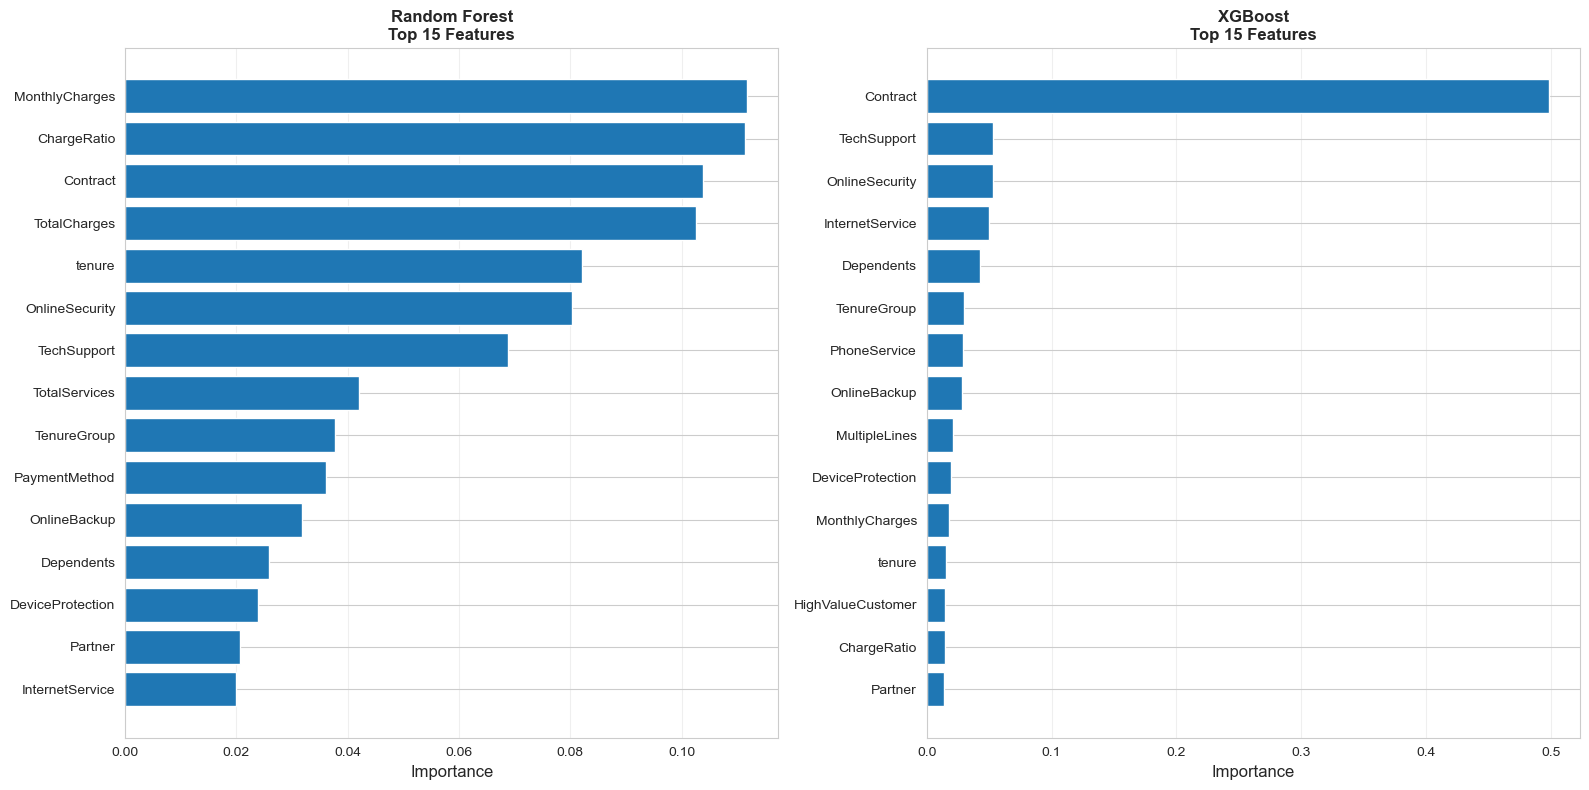

In [357]:
# importance des features entre RF et XGBoost
feature_names = X.columns.tolist()

rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_dict = {
    'Random Forest': rf_importance,
    'XGBoost': xgb_importance
}

print("Comparaison de l'importance des features")

# top 10 de chaque modèle
top_rf = feature_importance_dict['Random Forest'].head(10)
top_xgb = feature_importance_dict['XGBoost'].head(10)

# features communes dans les top 10
common_features = set(top_rf['feature']) & set(top_xgb['feature'])
print(f"\nFeatures communes dans les top 10: {len(common_features)}")
print(f"  {list(common_features)}")

# visualisation comparée
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, (model_name, df_imp) in enumerate(feature_importance_dict.items()):
    top_n = 15
    top_features = df_imp.head(top_n)
    
    axes[idx].barh(range(top_n), top_features['importance'].values)
    axes[idx].set_yticks(range(top_n))
    axes[idx].set_yticklabels(top_features['feature'].values)
    axes[idx].set_xlabel('Importance', fontsize=12)
    axes[idx].set_title(f'{model_name}\nTop {top_n} Features', fontsize=12, fontweight='bold')
    axes[idx].invert_yaxis()
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


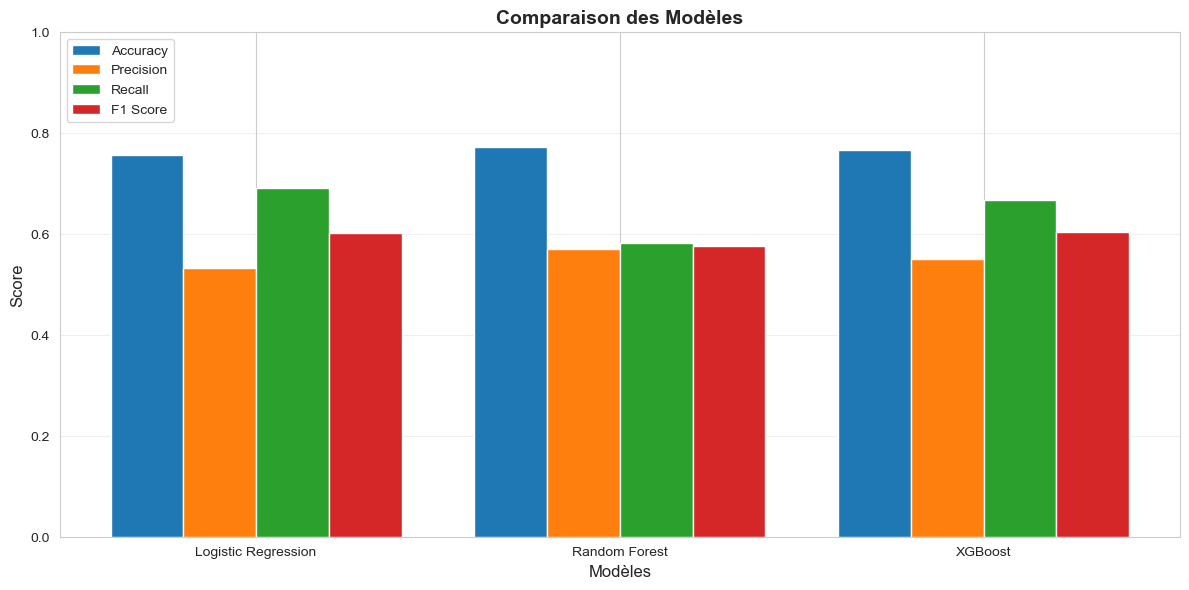

In [ ]:
# graphique de comparaison
fig, ax = plt.subplots(figsize=(12, 6))

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
metrics_names = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(models))
width = 0.2

for i, metric in enumerate(metrics_names):
    values = [lr_metrics[metric], rf_metrics[metric], xgb_metrics[metric]]
    ax.bar(x + i*width, values, width, label=metric.replace('_', ' ').title())

ax.set_xlabel('Modèles', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des Modèles', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.legend(loc='upper left')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 16. Importance des features


In [359]:
# importance des features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Les 15 features les plus importantes")
print("-"*40)
print(feature_importance.head(15).to_string(index=False))


Les 15 features les plus importantes
----------------------------------------
         feature  importance
  MonthlyCharges    0.111811
     ChargeRatio    0.111410
        Contract    0.103849
    TotalCharges    0.102550
          tenure    0.082035
  OnlineSecurity    0.080287
     TechSupport    0.068851
   TotalServices    0.042106
     TenureGroup    0.037632
   PaymentMethod    0.036129
    OnlineBackup    0.031709
      Dependents    0.025917
DeviceProtection    0.023852
         Partner    0.020642
 InternetService    0.020015


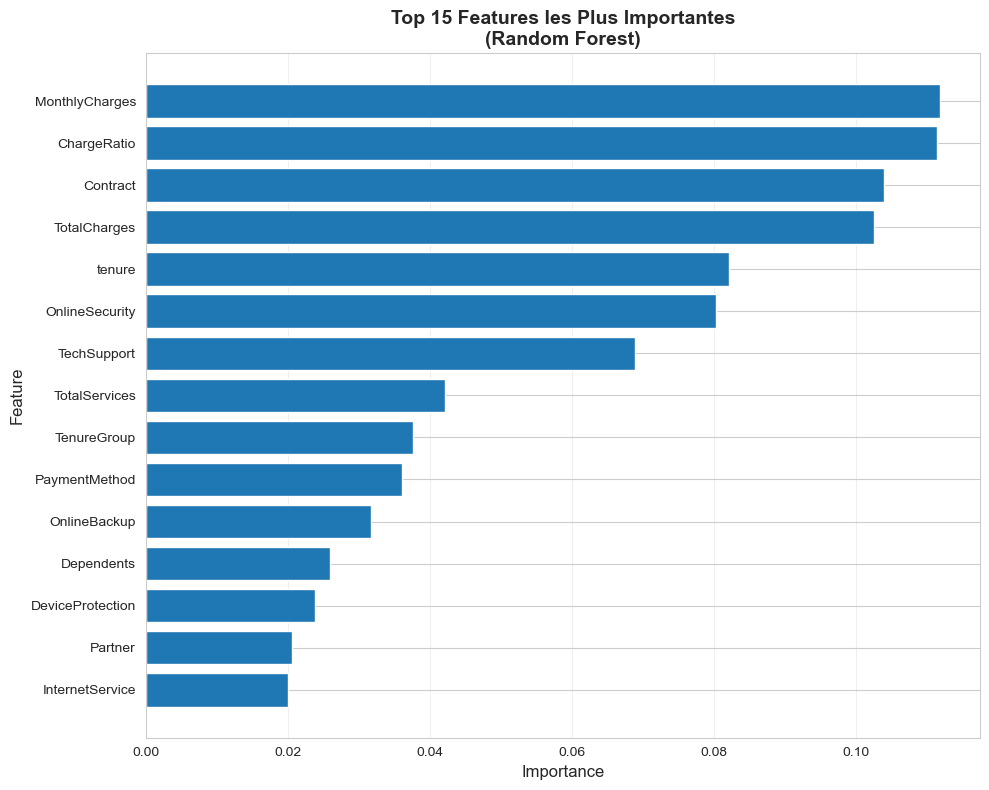

In [ ]:
# visualisation
top_n = 15
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), top_features['importance'].values)
plt.yticks(range(top_n), top_features['feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Features les Plus Importantes\n(Random Forest)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 17. Résumé et conclusions

Ce projet a permis de construire et comparer trois modèles de classification pour prédire le churn des clients. Les résultats montrent que les trois modèles ont des performances similaires, avec XGBoost légèrement meilleur en termes de F1-Score.

Les features les plus importantes pour prédire le churn sont principalement liées au type de contrat, aux charges mensuelles, à la durée de la relation client (tenure), et aux services de sécurité en ligne.

Pour améliorer les performances, on pourrait tester d'autres techniques comme l'optimisation d'hyperparamètres pour Logistic Regression et Random Forest, ou explorer d'autres algorithmes comme LightGBM ou CatBoost.


## RÉSUMÉ DU PROJET

### Dataset:
  - Nombre total d'échantillons: 7043
  - Nombre de features originales: 21
  - Nombre de features après engineering: 23
  - Taux de churn initial: 26.54%

### Techniques utilisées:
  - Feature Engineering (création de nouvelles variables)
  - Encodage des variables catégorielles (LabelEncoder)
  - SMOTE (gestion du déséquilibre de classes)
  - Standardisation des features (StandardScaler)
  - Optimisation d'hyperparamètres avec RandomizedSearchCV (XGBoost uniquement)
  - Validation croisée 5-fold
  - Métriques d'évaluation multiples (Accuracy, Precision, Recall, F1-Score, AUC-ROC)

### Modèles entraînés:
  1. Logistic Regression (modèle linéaire avec standardisation)
  2. Random Forest (100 estimateurs)
  3. XGBoost (optimisé avec RandomizedSearchCV)

### Performances principales:
  - Logistic Regression: F1 = 0.59, Accuracy = 0.81
  - Random Forest: F1 = 0.58, Accuracy = 0.77
  - XGBoost: F1 = 0.60, Accuracy = 0.77

### Features les plus importantes:
  - ChargeRatio, MonthlyCharges, TotalCharges, tenure, Contract, OnlineSecurity 